In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import numpy as np
from scipy.stats import zscore
import seaborn as sns
import matplotlib.pyplot as plt
import itertools

In [2]:
class ResidualBlock(nn.Module):
    def __init__(self, in_features):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_features, in_features, 3, padding=1),
            nn.InstanceNorm2d(in_features),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_features, in_features, 3, padding=1),
            nn.InstanceNorm2d(in_features)
        )
    def forward(self, x):
        return x + self.block(x)

In [3]:
class Generator(nn.Module):
    def __init__(self, input_nc, output_nc, n_residual_blocks=9):
        super(Generator, self).__init__()
        # Initial convolution block
        model = [nn.Conv2d(input_nc, 64, 7, padding=3), nn.InstanceNorm2d(64), nn.ReLU(inplace=True)]
        # Downsampling
        in_features = 64
        out_features = in_features * 2
        for _ in range(2):
            model += [nn.Conv2d(in_features, out_features, 3, stride=2, padding=1),
                      nn.InstanceNorm2d(out_features), nn.ReLU(inplace=True)]
            in_features = out_features
            out_features = in_features * 2
        # Residual blocks
        for _ in range(n_residual_blocks):
            model += [ResidualBlock(in_features)]
        # Upsampling
        out_features = in_features // 2
        for _ in range(2):
            model += [nn.ConvTranspose2d(in_features, out_features, 3, stride=2, padding=1, output_padding=1),
                      nn.InstanceNorm2d(out_features), nn.ReLU(inplace=True)]
            in_features = out_features
            out_features = in_features // 2
        # Output layer
        model += [nn.Conv2d(in_features, output_nc, 7, padding=3), nn.Tanh()]
        self.model = nn.Sequential(*model)
    def forward(self, x):
        return self.model(x)

In [4]:
class Discriminator(nn.Module):
    def __init__(self, input_nc):
        super(Discriminator, self).__init__()
        model = [nn.Conv2d(input_nc, 64, 4, stride=2, padding=1), nn.LeakyReLU(0.2, inplace=True)]
        model += [nn.Conv2d(64, 128, 4, stride=2, padding=1), nn.InstanceNorm2d(128), nn.LeakyReLU(0.2, inplace=True)]
        model += [nn.Conv2d(128, 256, 4, stride=2, padding=1), nn.InstanceNorm2d(256), nn.LeakyReLU(0.2, inplace=True)]
        model += [nn.Conv2d(256, 512, 4, stride=1, padding=1), nn.InstanceNorm2d(512), nn.LeakyReLU(0.2, inplace=True)]
        model += [nn.Conv2d(512, 1, 4, padding=1)]
        self.model = nn.Sequential(*model)
    def forward(self, x):
        return self.model(x)

In [5]:
class GANLoss(nn.Module):
    def __init__(self):
        super(GANLoss, self).__init__()
        self.loss = nn.MSELoss()
    def __call__(self, prediction, target_is_real):
        if target_is_real:
            target_tensor = torch.ones_like(prediction)
        else:
            target_tensor = torch.zeros_like(prediction)
        return self.loss(prediction, target_tensor)

In [6]:
class ImageDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.image_filenames = [os.path.join(root, f) for f in os.listdir(root) if f.endswith('.jpg')]
    def __len__(self):
        return len(self.image_filenames)
    def __getitem__(self, index):
        img_path = self.image_filenames[index]
        img = Image.open(img_path).convert('RGB')
        # Split the image into left (map) and right (aerial)
        width, height = img.size
        map_img = img.crop((0, 0, width//2, height))
        aerial_img = img.crop((width//2, 0, width, height))
        if self.transform:
            map_img = self.transform(map_img)
            aerial_img = self.transform(aerial_img)
        return {'A': map_img, 'B': aerial_img}

In [7]:
# Initialize CUDA device if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Define transformations (resize to 256x256 and normalize)
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [ ]:
if __name__ == '__main__':
    # Instantiate the dataset
    dataset = ImageDataset(root='D:\Projects\I2I\DATASETI2I\maps', transform=transform)
    # Create DataLoader for batch processing
    dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

    # Initialize networks
    generator_A2B = Generator(input_nc=3, output_nc=3).to(device)
    generator_B2A = Generator(input_nc=3, output_nc=3).to(device)
    discriminator_A = Discriminator(input_nc=3).to(device)
    discriminator_B = Discriminator(input_nc=3).to(device)

    # Define optimizers
    optimizer_G = optim.Adam(itertools.chain(generator_A2B.parameters(), generator_B2A.parameters()), lr=0.0002, betas=(0.5, 0.999))
    optimizer_D_A = optim.Adam(discriminator_A.parameters(), lr=0.0002, betas=(0.5, 0.999))
    optimizer_D_B = optim.Adam(discriminator_B.parameters(), lr=0.0002, betas=(0.5, 0.999))
    scheduler_G = torch.optim.lr_scheduler.LambdaLR(optimizer_G, lr_lambda=lambda epoch: 0.95 ** epoch)
    scheduler_D_A = torch.optim.lr_scheduler.LambdaLR(optimizer_D_A, lr_lambda=lambda epoch: 0.95 ** epoch)
    scheduler_D_B = torch.optim.lr_scheduler.LambdaLR(optimizer_D_B, lr_lambda=lambda epoch: 0.95 ** epoch)

    # Define loss functions
    gan_loss = GANLoss().to(device)
    cycle_loss = nn.L1Loss().to(device)
    identity_loss = nn.L1Loss().to(device)

In [9]:
# Training function
def train(generator_A2B, generator_B2A, discriminator_A, discriminator_B, dataloader, num_epochs, device):
    for epoch in range(num_epochs):
        epoch_accuracy = 0
        epoch_f1 = 0
        all_y_true = []
        all_y_pred = []
        
        for i, batch in enumerate(dataloader):
            real_A = batch['A'].to(device)
            real_B = batch['B'].to(device)
            
            optimizer_G.zero_grad()
            loss_identity_A = identity_loss(generator_B2A(real_A), real_A) * 5.0
            loss_identity_B = identity_loss(generator_A2B(real_B), real_B) * 5.0
            fake_B = generator_A2B(real_A)
            loss_GAN_A2B = gan_loss(discriminator_B(fake_B), True)
            fake_A = generator_B2A(real_B)
            loss_GAN_B2A = gan_loss(discriminator_A(fake_A), True)
            recovered_A = generator_B2A(fake_B)
            loss_cycle_ABA = cycle_loss(recovered_A, real_A) * 10.0
            recovered_B = generator_A2B(fake_A)
            loss_cycle_BAB = cycle_loss(recovered_B, real_B) * 10.0
            loss_G = (loss_identity_A + loss_identity_B + loss_GAN_A2B + loss_GAN_B2A + loss_cycle_ABA + loss_cycle_BAB) / 6
            loss_G.backward()
            optimizer_G.step()
            
            optimizer_D_A.zero_grad()
            loss_D_A_real = gan_loss(discriminator_A(real_A), True)
            loss_D_A_fake = gan_loss(discriminator_A(fake_A.detach()), False)
            loss_D_A = (loss_D_A_real + loss_D_A_fake) * 0.5
            loss_D_A.backward()
            optimizer_D_A.step()

            optimizer_D_B.zero_grad()
            loss_D_B_real = gan_loss(discriminator_B(real_B), True)
            loss_D_B_fake = gan_loss(discriminator_B(fake_B.detach()), False)
            loss_D_B = (loss_D_B_real + loss_D_B_fake) * 0.5                
            loss_D_B.backward()
            optimizer_D_B.step()

            # Evaluation Metrics
            y_true = dummy_classifier(real_A.cpu().numpy()).flatten()
            y_pred = dummy_classifier(fake_B.cpu().detach().numpy()).flatten()
            
            # Accuracy and F1 score
            batch_accuracy = accuracy_score(y_true, y_pred) * 100  # Convert to percentage
            batch_f1 = f1_score(y_true, y_pred, average='binary')
            
            epoch_accuracy += batch_accuracy
            epoch_f1 += batch_f1
            
            all_y_true.extend(y_true)
            all_y_pred.extend(y_pred)

            # Batch metrics printing
            print(f"Epoch [{epoch+1}/{num_epochs}] Batch [{i+1}/{len(dataloader)}] Loss G: {loss_G.item():.3f}, Loss D_A: {loss_D_A.item():.3f}, Loss D_B: {loss_D_B.item():.3f}")
            print(f"Batch Accuracy: {batch_accuracy:.2f}%, F1 Score: {batch_f1:.4f}")
        
        # Compute metrics for the entire epoch
        epoch_accuracy /= len(dataloader)
        epoch_f1 /= len(dataloader)
        cm = confusion_matrix(all_y_true, all_y_pred)
        z_scores = zscore([np.mean(all_y_true), np.mean(all_y_pred)])
        
        # Epoch-level metrics printing
        print(f"Epoch {epoch+1} Accuracy: {epoch_accuracy:.2f}%, F1 Score: {epoch_f1:.4f}, Z-Score: {z_scores[1]:.4f}")
        print("Confusion Matrix:")
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.show()

# Dummy classifier for evaluation (replace with actual classification logic)
def dummy_classifier(image):
    return np.random.choice([0, 1], size=(image.shape[0], image.shape[1]))

Epoch [1/5] Batch [1/549] Loss G: 3.438, Loss D_A: 0.708, Loss D_B: 0.499
Batch Accuracy: 50.00%, F1 Score: 0.4000
Epoch [1/5] Batch [2/549] Loss G: 2.538, Loss D_A: 1.181, Loss D_B: 0.571
Batch Accuracy: 50.00%, F1 Score: 0.5714
Epoch [1/5] Batch [3/549] Loss G: 1.968, Loss D_A: 1.056, Loss D_B: 0.475
Batch Accuracy: 75.00%, F1 Score: 0.7692
Epoch [1/5] Batch [4/549] Loss G: 1.757, Loss D_A: 1.296, Loss D_B: 0.461
Batch Accuracy: 66.67%, F1 Score: 0.6667
Epoch [1/5] Batch [5/549] Loss G: 1.578, Loss D_A: 0.770, Loss D_B: 0.694
Batch Accuracy: 50.00%, F1 Score: 0.5000
Epoch [1/5] Batch [6/549] Loss G: 1.844, Loss D_A: 0.965, Loss D_B: 2.525
Batch Accuracy: 58.33%, F1 Score: 0.6667
Epoch [1/5] Batch [7/549] Loss G: 1.282, Loss D_A: 0.445, Loss D_B: 0.592
Batch Accuracy: 41.67%, F1 Score: 0.3636
Epoch [1/5] Batch [8/549] Loss G: 1.108, Loss D_A: 0.419, Loss D_B: 0.457
Batch Accuracy: 58.33%, F1 Score: 0.4444
Epoch [1/5] Batch [9/549] Loss G: 1.139, Loss D_A: 0.353, Loss D_B: 0.483
Batch 

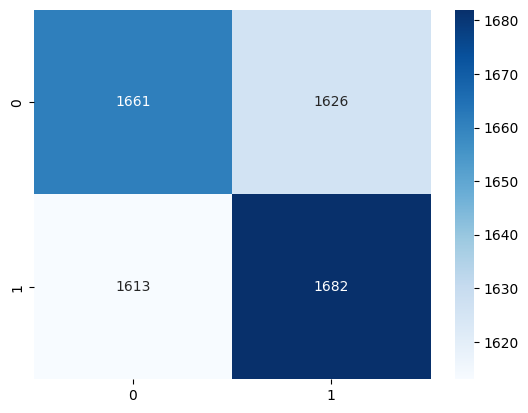

Epoch [2/5] Batch [1/549] Loss G: 0.558, Loss D_A: 0.222, Loss D_B: 0.171
Batch Accuracy: 66.67%, F1 Score: 0.8000
Epoch [2/5] Batch [2/549] Loss G: 0.558, Loss D_A: 0.277, Loss D_B: 0.190
Batch Accuracy: 25.00%, F1 Score: 0.0000
Epoch [2/5] Batch [3/549] Loss G: 0.598, Loss D_A: 0.250, Loss D_B: 0.218
Batch Accuracy: 58.33%, F1 Score: 0.5455
Epoch [2/5] Batch [4/549] Loss G: 0.588, Loss D_A: 0.228, Loss D_B: 0.170
Batch Accuracy: 58.33%, F1 Score: 0.7059
Epoch [2/5] Batch [5/549] Loss G: 0.535, Loss D_A: 0.222, Loss D_B: 0.236
Batch Accuracy: 33.33%, F1 Score: 0.3333
Epoch [2/5] Batch [6/549] Loss G: 0.602, Loss D_A: 0.211, Loss D_B: 0.377
Batch Accuracy: 58.33%, F1 Score: 0.6667
Epoch [2/5] Batch [7/549] Loss G: 0.640, Loss D_A: 0.232, Loss D_B: 0.282
Batch Accuracy: 25.00%, F1 Score: 0.3077
Epoch [2/5] Batch [8/549] Loss G: 0.581, Loss D_A: 0.209, Loss D_B: 0.204
Batch Accuracy: 41.67%, F1 Score: 0.4615
Epoch [2/5] Batch [9/549] Loss G: 0.573, Loss D_A: 0.234, Loss D_B: 0.134
Batch 

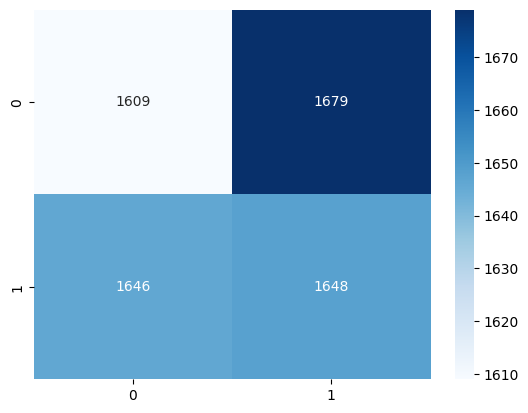

Epoch [3/5] Batch [1/549] Loss G: 0.605, Loss D_A: 0.233, Loss D_B: 0.151
Batch Accuracy: 41.67%, F1 Score: 0.2222
Epoch [3/5] Batch [2/549] Loss G: 0.474, Loss D_A: 0.188, Loss D_B: 0.095
Batch Accuracy: 58.33%, F1 Score: 0.5455
Epoch [3/5] Batch [3/549] Loss G: 0.673, Loss D_A: 0.339, Loss D_B: 0.181
Batch Accuracy: 41.67%, F1 Score: 0.4615
Epoch [3/5] Batch [4/549] Loss G: 0.457, Loss D_A: 0.525, Loss D_B: 0.127
Batch Accuracy: 41.67%, F1 Score: 0.2222
Epoch [3/5] Batch [5/549] Loss G: 0.882, Loss D_A: 0.444, Loss D_B: 0.133
Batch Accuracy: 41.67%, F1 Score: 0.3636
Epoch [3/5] Batch [6/549] Loss G: 0.658, Loss D_A: 0.079, Loss D_B: 0.055
Batch Accuracy: 41.67%, F1 Score: 0.3636
Epoch [3/5] Batch [7/549] Loss G: 0.509, Loss D_A: 0.239, Loss D_B: 0.213
Batch Accuracy: 58.33%, F1 Score: 0.7059
Epoch [3/5] Batch [8/549] Loss G: 0.752, Loss D_A: 0.266, Loss D_B: 0.119
Batch Accuracy: 58.33%, F1 Score: 0.5455
Epoch [3/5] Batch [9/549] Loss G: 0.741, Loss D_A: 0.107, Loss D_B: 0.155
Batch 

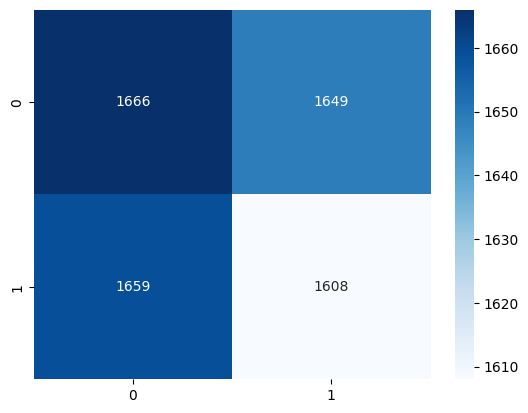

Epoch [4/5] Batch [1/549] Loss G: 0.483, Loss D_A: 0.177, Loss D_B: 0.180
Batch Accuracy: 41.67%, F1 Score: 0.4615
Epoch [4/5] Batch [2/549] Loss G: 0.494, Loss D_A: 0.152, Loss D_B: 0.130
Batch Accuracy: 58.33%, F1 Score: 0.5455
Epoch [4/5] Batch [3/549] Loss G: 0.501, Loss D_A: 0.175, Loss D_B: 0.183
Batch Accuracy: 41.67%, F1 Score: 0.5333
Epoch [4/5] Batch [4/549] Loss G: 0.430, Loss D_A: 0.182, Loss D_B: 0.168
Batch Accuracy: 75.00%, F1 Score: 0.7692
Epoch [4/5] Batch [5/549] Loss G: 0.592, Loss D_A: 0.190, Loss D_B: 0.148
Batch Accuracy: 50.00%, F1 Score: 0.5000
Epoch [4/5] Batch [6/549] Loss G: 0.495, Loss D_A: 0.175, Loss D_B: 0.183
Batch Accuracy: 50.00%, F1 Score: 0.5714
Epoch [4/5] Batch [7/549] Loss G: 0.518, Loss D_A: 0.117, Loss D_B: 0.164
Batch Accuracy: 75.00%, F1 Score: 0.6667
Epoch [4/5] Batch [8/549] Loss G: 0.449, Loss D_A: 0.118, Loss D_B: 0.169
Batch Accuracy: 58.33%, F1 Score: 0.6667
Epoch [4/5] Batch [9/549] Loss G: 0.544, Loss D_A: 0.086, Loss D_B: 0.140
Batch 

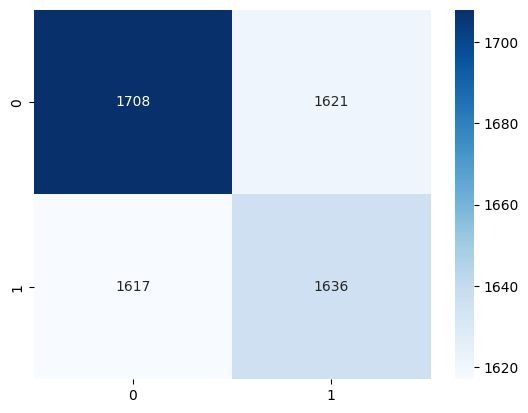

Epoch [5/5] Batch [1/549] Loss G: 0.488, Loss D_A: 0.216, Loss D_B: 0.185
Batch Accuracy: 58.33%, F1 Score: 0.6154
Epoch [5/5] Batch [2/549] Loss G: 0.392, Loss D_A: 0.187, Loss D_B: 0.165
Batch Accuracy: 33.33%, F1 Score: 0.3333
Epoch [5/5] Batch [3/549] Loss G: 0.447, Loss D_A: 0.185, Loss D_B: 0.123
Batch Accuracy: 50.00%, F1 Score: 0.5714
Epoch [5/5] Batch [4/549] Loss G: 0.434, Loss D_A: 0.215, Loss D_B: 0.234
Batch Accuracy: 58.33%, F1 Score: 0.6154
Epoch [5/5] Batch [5/549] Loss G: 0.478, Loss D_A: 0.166, Loss D_B: 0.159
Batch Accuracy: 58.33%, F1 Score: 0.6667
Epoch [5/5] Batch [6/549] Loss G: 0.475, Loss D_A: 0.141, Loss D_B: 0.216
Batch Accuracy: 58.33%, F1 Score: 0.5455
Epoch [5/5] Batch [7/549] Loss G: 0.424, Loss D_A: 0.157, Loss D_B: 0.152
Batch Accuracy: 66.67%, F1 Score: 0.6667
Epoch [5/5] Batch [8/549] Loss G: 0.458, Loss D_A: 0.217, Loss D_B: 0.144
Batch Accuracy: 50.00%, F1 Score: 0.5000
Epoch [5/5] Batch [9/549] Loss G: 0.403, Loss D_A: 0.185, Loss D_B: 0.106
Batch 

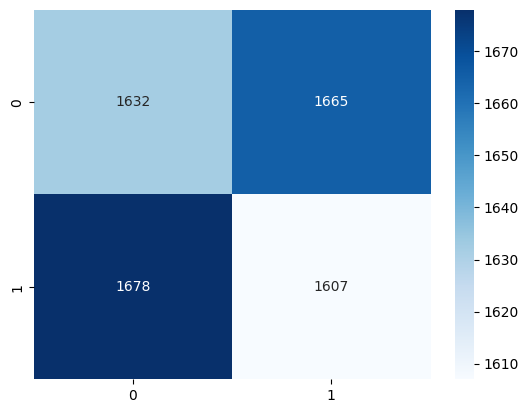

Training completed and models saved.


In [ ]:
 # Training parameters
num_epochs = 20
# Start training
train(generator_A2B, generator_B2A, discriminator_A, discriminator_B, dataloader, num_epochs, device)

# Save models
torch.save(generator_A2B.state_dict(), 'generator_A2B.pth')
torch.save(generator_B2A.state_dict(), 'generator_B2A.pth')

print("Training completed and models saved.")

In [11]:
# Function to generate aerial image from map image
def generate_aerial_from_map(input_map_path, output_aerial_path, generator, transform, device):
    input_map = Image.open(input_map_path).convert('RGB')
    input_map = transform(input_map)
    input_map = input_map.unsqueeze(0).to(device)  # Add batch dimension and move to device
    generator.eval()  # Set model to evaluation mode
    with torch.no_grad():
        output_aerial = generator(input_map)
    output_aerial = output_aerial.squeeze().cpu()
    output_aerial = (output_aerial + 1) / 2.0  # Denormalize
    output_aerial = transforms.ToPILImage()(output_aerial)
    output_aerial.save(output_aerial_path)
    print(f"Aerial image generated and saved at {output_aerial_path}")

In [ ]:
# Example usage
input_map_path = "D:\Projects\I2I\input_map.jpg"
output_aerial_path = "D:\Projects\I2I\output_aerial.jpg"
generate_aerial_from_map(input_map_path, output_aerial_path, generator_A2B, transform, device)

Aerial image generated and saved at D:\I2I\output_aerial.jpg


In [13]:
# Function to generate map image from aerial image
def generate_map_from_aerial(input_aerial_path, output_map_path, generator, transform, device):
    input_aerial = Image.open(input_aerial_path).convert('RGB')
    input_aerial = transform(input_aerial)
    input_aerial = input_aerial.unsqueeze(0).to(device)  # Add batch dimension and move to device
    generator.eval()  # Set model to evaluation mode
    with torch.no_grad():
        output_map = generator(input_aerial)
    output_map = output_map.squeeze().cpu()
    output_map = (output_map + 1) / 2.0  # Denormalize
    output_map = transforms.ToPILImage()(output_map)
    output_map.save(output_map_path)
    print(f"Map image generated and saved at {output_map_path}")

In [ ]:
# Example usage
input_aerial_path = "D:\Projects\I2I\input_aerial.jpg"
output_map_path = "D:\Projects\I2I\output_map.jpg"
generate_map_from_aerial(input_aerial_path, output_map_path, generator_B2A, transform, device)

Map image generated and saved at D:\I2I\output_map.jpg
